# Task 4A: Direct LoRA Fine-Tuning — RIAWELC Weld Defects

Image + Prompt → JSON (no reasoning)

24 images (6 per class × 4 classes), 40 epochs.

## Setup

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import json, re, time, torch, gc, random
import numpy as np
from PIL import Image
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
from config import *

random.seed(SEED)
for i in range(torch.cuda.device_count()):
    print(f'GPU {i}: {torch.cuda.get_device_name(i)} — {torch.cuda.get_device_properties(i).total_memory/1e9:.1f} GB')

GPU 0: Tesla V100-PCIE-16GB — 16.9 GB
GPU 1: Tesla V100-PCIE-16GB — 16.9 GB


## Step 1: Select Training Images

In [2]:
train_data = []
for cls in CLASSES:
    cls_dir = os.path.join(TRAIN_IMAGES_DIR, cls)
    all_imgs = sorted([f for f in os.listdir(cls_dir) if f.endswith('.png')])
    selected = random.sample(all_imgs, IMAGES_PER_CLASS)
    for img_name in selected:
        train_data.append({'image': os.path.join(cls_dir, img_name), 'class': cls})
    print(f'{cls}: {len(selected)} selected from {len(all_imgs)}')
print(f'\nTotal: {len(train_data)} training images')

lack_of_penetration: 6 selected from 4962
porosity: 6 selected from 4108
cracks: 6 selected from 2893
no_defect: 6 selected from 3900

Total: 24 training images


## Step 2: Create Training Data

In [3]:
PROMPT = make_prompt()
print(f'Prompt ({len(PROMPT)} chars):\n{PROMPT[:200]}...\n')

direct_data = []
for entry in train_data:
    gt_json = json.dumps({'defect_class': entry['class']})
    direct_data.append({'messages': [
        {'role': 'user', 'content': [{'type': 'image', 'image': entry['image']}, {'type': 'text', 'text': PROMPT}]},
        {'role': 'assistant', 'content': gt_json},
    ]})

with open('training_data_direct.jsonl', 'w') as f:
    for r in direct_data: f.write(json.dumps(r) + '\n')
print(f'Saved {len(direct_data)} examples to training_data_direct.jsonl')

Prompt (1221 chars):
Classify this weld radiographic image.

This is a 227×227 pixel 8-bit grayscale radiographic (X-ray) image of a weld joint. Radiography reveals internal defects as variations in image intensity — defe...

Saved 24 examples to training_data_direct.jsonl


## Step 3: Load Model + LoRA

In [4]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from peft import LoraConfig, get_peft_model, PeftModel
from transformers import get_cosine_schedule_with_warmup
from torch.utils.data import Dataset

processor = AutoProcessor.from_pretrained(MODEL_ID, min_pixels=256*28*28, max_pixels=512*28*28, use_fast=False)
base_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID, device_map='auto', dtype=torch.bfloat16,
    max_memory={0: '6GiB', 1: '15GiB'})
base_model.enable_input_require_grads()

lora_config = LoraConfig(r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGETS, task_type='CAUSAL_LM', bias='none')

print(f'Model loaded (BF16).')
for i in range(torch.cuda.device_count()):
    print(f'  GPU {i}: {torch.cuda.memory_allocated(i)/1e9:.1f} GB')

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.21it/s]


Model loaded (BF16).
  GPU 0: 3.7 GB
  GPU 1: 3.9 GB


## Step 4: Dataset + Training

In [5]:
class WeldDataset(Dataset):
    def __init__(self, jsonl_path, processor):
        with open(jsonl_path) as f:
            self.data = [json.loads(line) for line in f]
        self.processor = processor
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        entry = self.data[idx]
        msgs = entry['messages']
        img_path = next((c['image'] for c in msgs[0]['content'] if c['type']=='image'), None)
        user_text = next((c['text'] for c in msgs[0]['content'] if c['type']=='text'), '')
        assistant_text = msgs[1]['content']
        if not isinstance(assistant_text, str): assistant_text = json.dumps(assistant_text)
        image = Image.open(img_path).convert('RGB') if img_path else None
        chat = [{'role':'user','content':[{'type':'image','image':image},{'type':'text','text':user_text}]},
                {'role':'assistant','content':[{'type':'text','text':assistant_text}]}]
        text = self.processor.apply_chat_template(chat, tokenize=False, add_generation_prompt=False)
        inputs = self.processor(text=[text], images=[image], return_tensors='pt', padding=True)
        input_ids = inputs['input_ids'].squeeze(0)
        labels = input_ids.clone()
        ast_tokens = self.processor.tokenizer.encode(assistant_text, add_special_tokens=False)
        if len(ast_tokens) < len(labels): labels[:-len(ast_tokens)] = -100
        if image: image.close()
        return {'input_ids': input_ids, 'attention_mask': inputs['attention_mask'].squeeze(0),
                'labels': labels, 'pixel_values': inputs.get('pixel_values', None),
                'image_grid_thw': inputs.get('image_grid_thw', None)}

print('Dataset class ready.')

Dataset class ready.


In [6]:
EPOCHS = 40
LR = 2e-5
GRAD_ACCUM = 4

def train_lora(base_model, data_path, output_dir, epochs=EPOCHS, lr=LR):
    model = get_peft_model(base_model, lora_config)
    model.gradient_checkpointing_enable()
    model.print_trainable_parameters()
    dataset = WeldDataset(data_path, processor)
    print(f'Training: {len(dataset)} examples, {epochs} epochs, lr={lr}')
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = max(len(dataset) * epochs // GRAD_ACCUM, 1)
    scheduler = get_cosine_schedule_with_warmup(optimizer, int(total_steps*0.1), total_steps)
    model.train()
    losses = []
    t_start = time.time()
    for epoch in range(epochs):
        epoch_loss = 0
        for i in range(len(dataset)):
            batch = dataset[i]
            ids = batch['input_ids'].unsqueeze(0).to(model.device)
            mask = batch['attention_mask'].unsqueeze(0).to(model.device)
            lab = batch['labels'].unsqueeze(0).to(model.device)
            kw = {'input_ids':ids,'attention_mask':mask,'labels':lab}
            if batch.get('pixel_values') is not None: kw['pixel_values']=batch['pixel_values'].to(model.device)
            if batch.get('image_grid_thw') is not None: kw['image_grid_thw']=batch['image_grid_thw'].to(model.device)
            out = model(**kw)
            loss = out.loss / GRAD_ACCUM
            loss.backward()
            epoch_loss += loss.item() * GRAD_ACCUM
            if (i+1) % GRAD_ACCUM == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); scheduler.step(); optimizer.zero_grad()
            del ids, mask, lab, out, loss; torch.cuda.empty_cache()
        avg = epoch_loss / len(dataset)
        losses.append(avg)
        if (epoch+1) % 5 == 0 or epoch == 0:
            elapsed = time.time() - t_start
            print(f'  Epoch {epoch+1}/{epochs} — loss: {avg:.4f} — lr: {scheduler.get_last_lr()[0]:.2e} — {elapsed:.0f}s')
    os.makedirs(output_dir, exist_ok=True)
    model.save_pretrained(output_dir)
    print(f'Adapter saved to {output_dir}/')
    plt.figure(figsize=(8,4))
    plt.plot(range(1,len(losses)+1), losses)
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title(f'Training Loss ({output_dir})')
    plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()
    return model, losses

print('Training function ready.')

Training function ready.


trainable params: 37,152,768 || all params: 3,791,775,744 || trainable%: 0.9798
Training: 24 examples, 40 epochs, lr=2e-05


/anaconda/envs/azureml_py38/lib/python3.10/site-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...
/anaconda/envs/azureml_py38/lib/python3.10/site-packages/torch/autograd/graph.py:865: UserWarning: The AccumulateGrad node's stream does not match the stream of the node that produced the incoming gradient. This may incur unnecessary synchronization and break CUDA graph capture if the AccumulateGrad node's stream is the default stream. This mismatch is caused by an AccumulateGrad node created prior to the current iteration being kept alive. This can happen if the autograd graph is still being kept alive by tensors such as the loss, or if you are using DDP, which will stash a reference to the node. To resolve the mismatch, delete all references to the autograd graph or ensure that DDP initialization i

  Epoch 1/40 — loss: 0.1739 — lr: 5.00e-06 — 45s
  Epoch 5/40 — loss: 0.1028 — lr: 2.00e-05 — 223s
  Epoch 10/40 — loss: 0.0563 — lr: 1.87e-05 — 445s
  Epoch 15/40 — loss: 0.0235 — lr: 1.57e-05 — 668s
  Epoch 20/40 — loss: 0.0062 — lr: 1.17e-05 — 893s
  Epoch 25/40 — loss: 0.0004 — lr: 7.41e-06 — 1118s
  Epoch 30/40 — loss: 0.0002 — lr: 3.57e-06 — 1343s
  Epoch 35/40 — loss: 0.0002 — lr: 9.37e-07 — 1567s
  Epoch 40/40 — loss: 0.0002 — lr: 0.00e+00 — 1792s
Adapter saved to lora_direct/


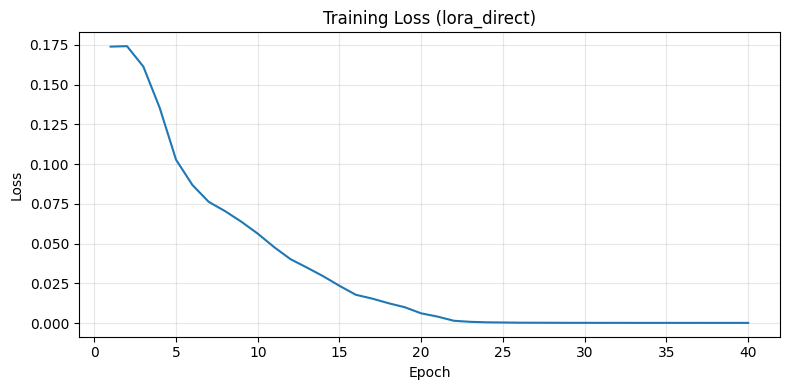

In [7]:
model, losses = train_lora(base_model, 'training_data_direct.jsonl', 'lora_direct', epochs=EPOCHS, lr=LR)

## Step 5: Evaluate on Test Set (240 sampled images)

In [8]:
SAMPLE_PER_CLASS = 60  # same as benchmarking

def parse_response(raw):
    if not raw: return None
    raw = raw.replace('<','').replace('>','')
    raw = re.sub(r'```json\s*','',raw); raw = re.sub(r'```\s*','',raw).strip()
    try:
        obj = json.loads(raw)
        if isinstance(obj, dict): return obj
    except: pass
    m = re.search(r'\{.*\}', raw, re.DOTALL)
    if m:
        try: return json.loads(m.group())
        except: pass
    dm = re.search(r'"defect_class"\s*:\s*"([\w]+)"', raw)
    if dm: return {'defect_class': dm.group(1)}
    raw_lower = raw.lower()
    for cls in sorted(CLASSES, key=len, reverse=True):
        if cls in raw_lower: return {'defect_class': cls}
    return None

def build_test_manifest():
    random.seed(SEED)
    manifest = []
    for cls in CLASSES:
        cls_dir = os.path.join(TEST_IMAGES_DIR, cls)
        images = sorted([f for f in os.listdir(cls_dir) if f.endswith('.png')])
        if len(images) > SAMPLE_PER_CLASS:
            images = random.sample(images, SAMPLE_PER_CLASS)
        for img in images:
            manifest.append({'image': os.path.join(cls_dir, img), 'class': cls})
    random.shuffle(manifest)
    return manifest

def evaluate(model, processor, manifest, prompt):
    model.eval()
    results = []; correct = 0; valid = 0; total_time = 0
    print(f'Evaluating on {len(manifest)} images...')
    for i, entry in enumerate(manifest):
        image = Image.open(entry['image']).convert('RGB')
        msgs = [{'role':'user','content':[{'type':'image','image':image},{'type':'text','text':prompt}]}]
        text = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text], images=[image], return_tensors='pt', padding=True).to(model.device)
        t = time.time()
        with torch.no_grad():
            ids = model.generate(**inputs, max_new_tokens=256, temperature=0.1, do_sample=True)
        elapsed = time.time() - t; total_time += elapsed
        out = processor.batch_decode(ids[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)[0].strip()
        parsed = parse_response(out)
        gt = entry['class']; ok = False
        if parsed:
            valid += 1
            pred = parsed.get('defect_class', '').lower().strip()
            if pred == gt: ok = True; correct += 1
        results.append({'image': entry['image'], 'class': gt, 'predicted': parsed,
            'raw': out, 'correct': ok, 'valid_json': parsed is not None, 'time_s': round(elapsed, 2)})
        del inputs, ids; image.close(); torch.cuda.empty_cache()
        if (i+1) % 60 == 0:
            n = i+1; print(f'  [{n}/{len(manifest)}] Acc: {correct}/{n} ({correct/n*100:.0f}%)')
    return results, correct, valid, total_time

print('Eval functions ready.')

Eval functions ready.


In [9]:
test_manifest = build_test_manifest()
print(f'Test set: {len(test_manifest)} images')
PROMPT = make_prompt()
results, correct, valid, eval_time = evaluate(model, processor, test_manifest, PROMPT)
n = len(results)
print(f'\nDirect LoRA: {correct}/{n} ({correct/n*100:.1f}%) | JSON: {valid}/{n} | {eval_time/n:.1f}s/img')

print(f'\nPer-class:')
by_class = defaultdict(list)
for r in results: by_class[r['class']].append(r)
for cls in CLASSES:
    cr = by_class[cls]; c = sum(1 for r in cr if r['correct'])
    print(f'  {cls:<24} {c:>3}/{len(cr)} ({c/len(cr)*100:.0f}%)')

Test set: 240 images
Evaluating on 240 images...
  [60/240] Acc: 45/60 (75%)
  [120/240] Acc: 90/120 (75%)
  [180/240] Acc: 130/180 (72%)
  [240/240] Acc: 176/240 (73%)

Direct LoRA: 176/240 (73.3%) | JSON: 240/240 | 3.1s/img

Per-class:
  lack_of_penetration       39/60 (65%)
  porosity                  50/60 (83%)
  cracks                    35/60 (58%)
  no_defect                 52/60 (87%)


In [10]:
with open('results_direct.json', 'w') as f:
    json.dump({'model': MODEL_ID, 'method': 'direct_lora', 'dataset': 'RIAWELC',
        'total_images': n, 'accuracy_pct': round(correct/n*100, 1),
        'json_validity_pct': round(valid/n*100, 1), 'avg_inference_time_s': round(eval_time/n, 2),
        'training_images': len(direct_data), 'epochs': EPOCHS, 'lr': LR,
        'results': results}, f, indent=2)
print('Saved results_direct.json')

Saved results_direct.json
